# Test 2: full population inference

In [1]:
import numpy as np

In [2]:
import torch

In [3]:
import emcee
import corner as DFM
import matplotlib.pyplot as plt

In [4]:
from px2cosmo import fm as FM 
from px2cosmo import util as UT

## generate mock observation

In [5]:
phi_true = np.array([-1.65, -1.5, -0.2, -19.5]) # fit by eye to zeus21 output

# sample LF 
X_obs = FM.forwardmodel(phi_true, name='test2')

In [ ]:
fig = DFM.corner(X_obs[:,:2][:,::-1], labels=[r"$M_{\rm UV}$", "$z$"], 
                 color='k', hist_kwargs={'density':True})
plt.show()

In [6]:
_X_obs = torch.tensor(X_obs[:,:2].astype(np.float32)) #.to('mps')
_X_obs_sig = torch.tensor(X_obs[:,2:].astype(np.float32))
_logN_obs = torch.tensor(np.log(X_obs.shape[0]).astype(np.float32))

## load NDEs of $p(\log N|\phi)$ and $p(X|\phi)$

In [7]:
p_phi_logN = torch.load('/Users/chang/data/px2cosmo/test2/mock2_p_phi_logN.pt', weights_only=False) 
p_X_phisig = torch.load('/Users/chang/data/px2cosmo/test2/mock2_p_X_phisig.pt', weights_only=False)

## set up posterior

In [8]:
def log_prior(phi): 
    alpha, beta, gamma, Muv_s = phi
    if -1.8 < alpha < -1.5 and -1.8 < beta < -1.2 and -0.4 < gamma < 0 and -22 < Muv_s < -18: 
        return 0.
    return -np.inf

In [9]:
def log_posterior(phi, silent=True): 
    lp = log_prior(phi)
    if not np.isfinite(lp):
        return -np.inf

    _phi = torch.tensor(phi.astype(np.float32))
    # log likelihood
    _phisig = torch.cat([_phi.expand(X_obs.shape[0], -1), _X_obs_sig], dim=1)
    logp = p_X_phisig.log_prob_batched(_X_obs, _phisig, norm_posterior=False).sum().item()

    # log Poisson
    logp2 = p_phi_logN.log_prob(_phi, _logN_obs, norm_posterior=False).item()
    if not silent: print(logp, logp2)
        
    return logp + logp2

In [10]:
def log_posterior0(phi, silent=True): 
    lp = log_prior(phi)
    if not np.isfinite(lp):
        return -np.inf

    _phi = torch.tensor(phi.astype(np.float32))        
    return p_phi_logN.log_prob(_phi, _logN_obs, norm_posterior=False).item()

def log_posterior1(phi, silent=True): 
    lp = log_prior(phi)
    if not np.isfinite(lp):
        return -np.inf
        
    _phi = torch.tensor(phi.astype(np.float32))
    # log likelihood
    _phisig = torch.cat([_phi.expand(X_obs.shape[0], -1), _X_obs_sig], dim=1)
    logp = p_X_phisig.log_prob_batched(_X_obs, _phisig, norm_posterior=False).sum().item()        
    return logp

In [11]:
print(log_posterior(phi_true, silent=False))

-19234.8203125 5.362477779388428
-19229.45783472061


In [12]:
for _ in range(5): 
    _alpha = np.random.uniform(-1.8, -1.5) 
    _beta = np.random.uniform(-1.8, -1.2)
    _gamma = np.random.uniform(-0.4, 0.0) 
    _Muv_s = np.random.uniform(-22., -18.)
    _phi = np.array([_alpha, _beta, _gamma, _Muv_s])
    print(log_posterior(_phi, silent=False))

-19786.09375 -920587.4375
-940373.53125
-19556.1484375 -2008816.5
-2028372.6484375
-20463.90234375 -1152.423583984375
-21616.325927734375
-19759.267578125 -11505156.0
-11524915.267578125
-19731.68359375 -4324.7080078125
-24056.3916015625


In [13]:
%timeit log_posterior(phi_true)

11.9 ms ± 330 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [14]:
ndim, nwalkers = 4, 10
p0 = np.array([
  np.random.uniform(-1.8, -1.5, nwalkers),
  np.random.uniform(-1.8, -1.2, nwalkers),
  np.random.uniform(-0.4,  0.0, nwalkers),
  np.random.uniform(-22.,  -18., nwalkers),
]).T

In [15]:
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior)
_ = sampler.run_mcmc(p0, 10000, progress=True)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [02:17<00:00,  7.25it/s]


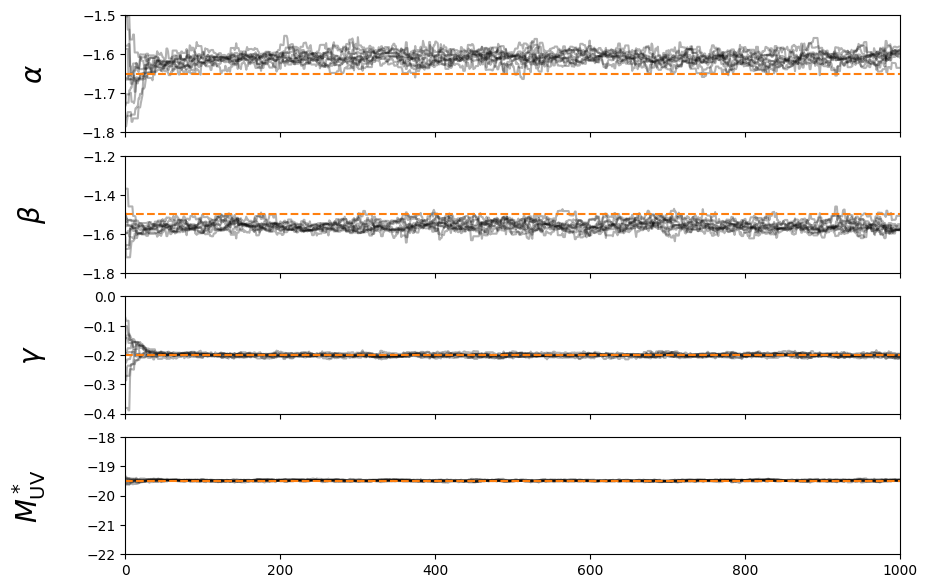

In [16]:
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.plot([0, samples.shape[0]], [phi_true[i], phi_true[i]], c='C1', ls='--')
    ax.set_xlim(0, len(samples))
    ax.set_ylabel([r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$'][i], fontsize=20)
    ax.yaxis.set_label_coords(-0.1, 0.5)
    ax.set_ylim([(-1.8, -1.5), (-1.8, -1.2), (-0.4, 0.0), (-22, -18)][i])

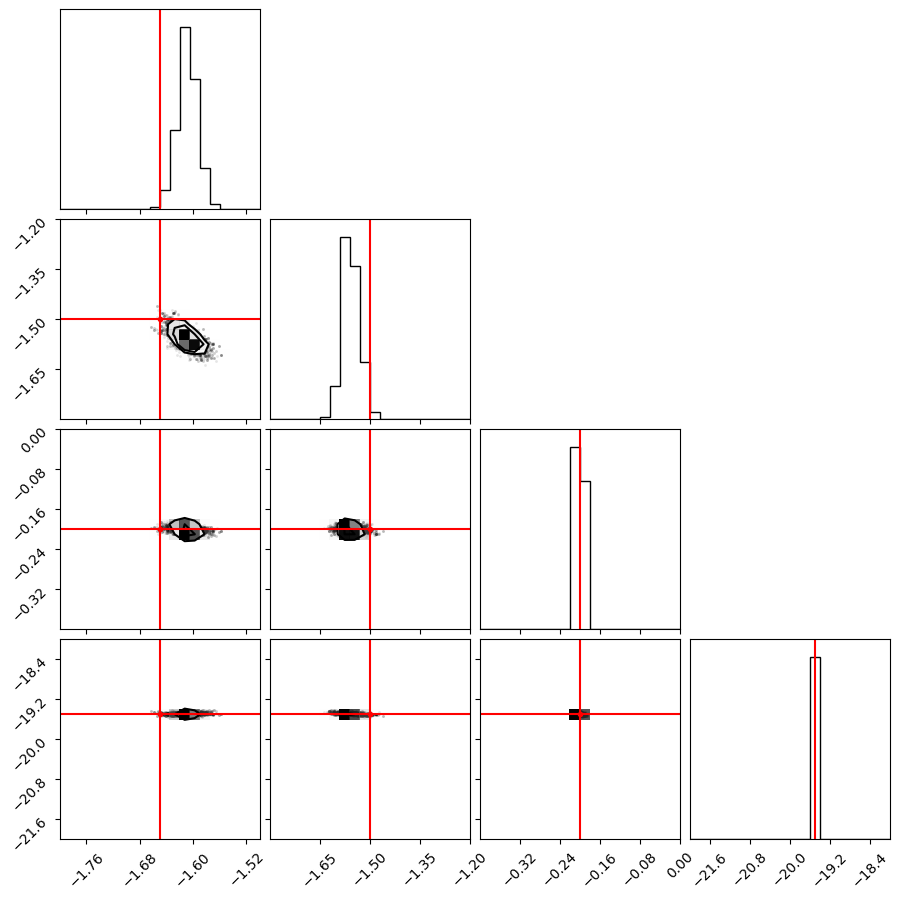

In [17]:
fig = DFM.corner(sampler.flatchain[5000:,:], range=[(-1.8, -1.5), (-1.8, -1.2), (-0.4, 0.0), (-22, -18)])
DFM.overplot_points(fig, [phi_true], color='red')
DFM.overplot_lines(fig, phi_true, color='red')
#DFM.overplot_lines(fig, np.median(sampler.flatchain[5000:,:], axis=0), color='blue')

In [18]:
log_posterior(phi_true, silent=False)

-19234.8203125 5.362477779388428


-19229.45783472061

In [19]:
log_posterior(np.median(sampler.flatchain[5000:,:], axis=0), silent=False)

-19230.58984375 6.146914482116699


-19224.442929267883

In [30]:
_XX = FM.forwardmodel(np.median(sampler.flatchain[5000:,:], axis=0), name='test2')

In [36]:
_XX.shape

(6382, 4)

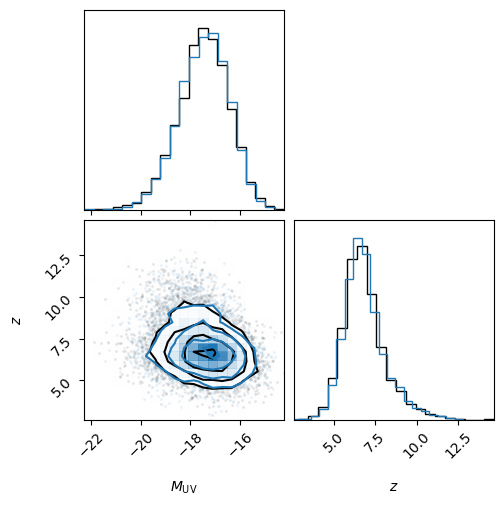

In [41]:
fig = DFM.corner(X_obs[:,:2][:,::-1], labels=[r"$M_{\rm UV}$", "$z$"], color='k', hist_kwargs={'density':True})
fig = DFM.corner(_XX[:,:2][:,::-1], labels=[r"$M_{\rm UV}$", "$z$"], color='C0', hist_kwargs={'density':True}, fig=fig)
plt.show()

(2e-05, 0.1)

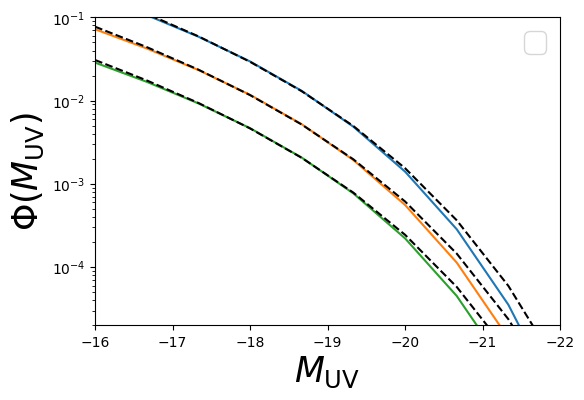

In [40]:
fig = plt.figure(figsize=(6,4))
sub = fig.add_subplot(111)

phi_amp = 6e-3
Muv_bin = np.linspace(-16, -22, 10)
for i, z0 in enumerate([5., 7., 9.]): 
    sub.plot(Muv_bin, phi_amp*UT.LF(Muv_bin, z0, np.median(sampler.flatchain[5000:,:], axis=0)), c='C%i' % i)

    sub.plot(Muv_bin, phi_amp*UT.LF(Muv_bin, z0, phi_true), c='k', ls='--')

sub.legend(loc='upper right', handletextpad=0.1, fontsize=20)
sub.set_xlabel(r'$M_{\rm UV}$', fontsize=25)
sub.set_xlim(-16, -22)
sub.set_yscale('log')
sub.set_ylabel(r'$\Phi(M_{\rm UV})$', fontsize=25)
plt.ylim(2e-5, 1e-1)

In [20]:
_XX = FM.forwardmodel(np.median(sampler.flatchain[5000:,:], axis=0), name='test2')

In [23]:
ndim, nwalkers = 4, 10
var = np.array([0.1, 0.1, 0.1, 0.1])
p0 = phi_true[None,:] + var[None,:]*np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior0)
_ = sampler.run_mcmc(p0, 1000, progress=True)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:06<00:00, 151.41it/s]


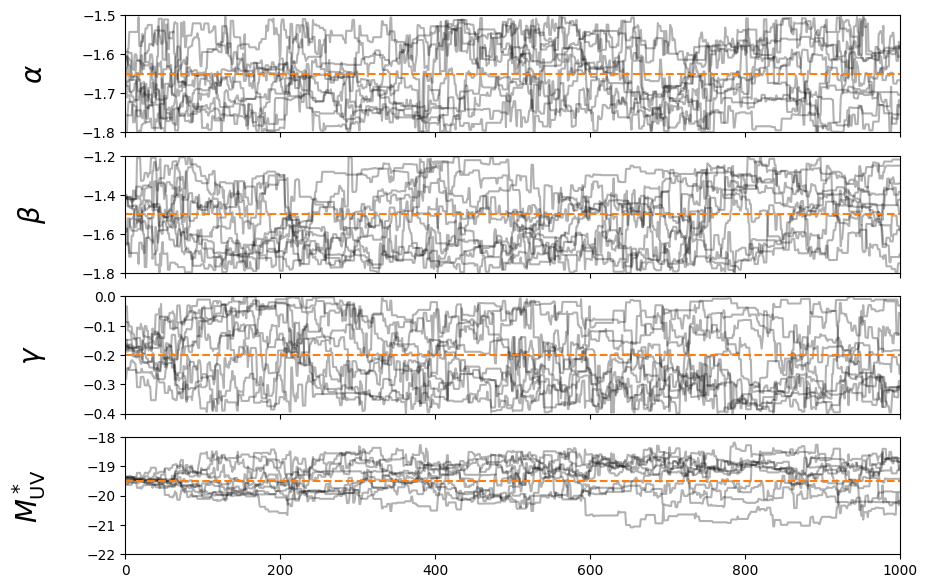

In [24]:
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.plot([0, samples.shape[0]], [phi_true[i], phi_true[i]], c='C1', ls='--')
    ax.set_xlim(0, len(samples))
    ax.set_ylabel([r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$'][i], fontsize=20)
    ax.yaxis.set_label_coords(-0.1, 0.5)
    ax.set_ylim([(-1.8, -1.5), (-1.8, -1.2), (-0.4, 0.0), (-22, -18)][i])

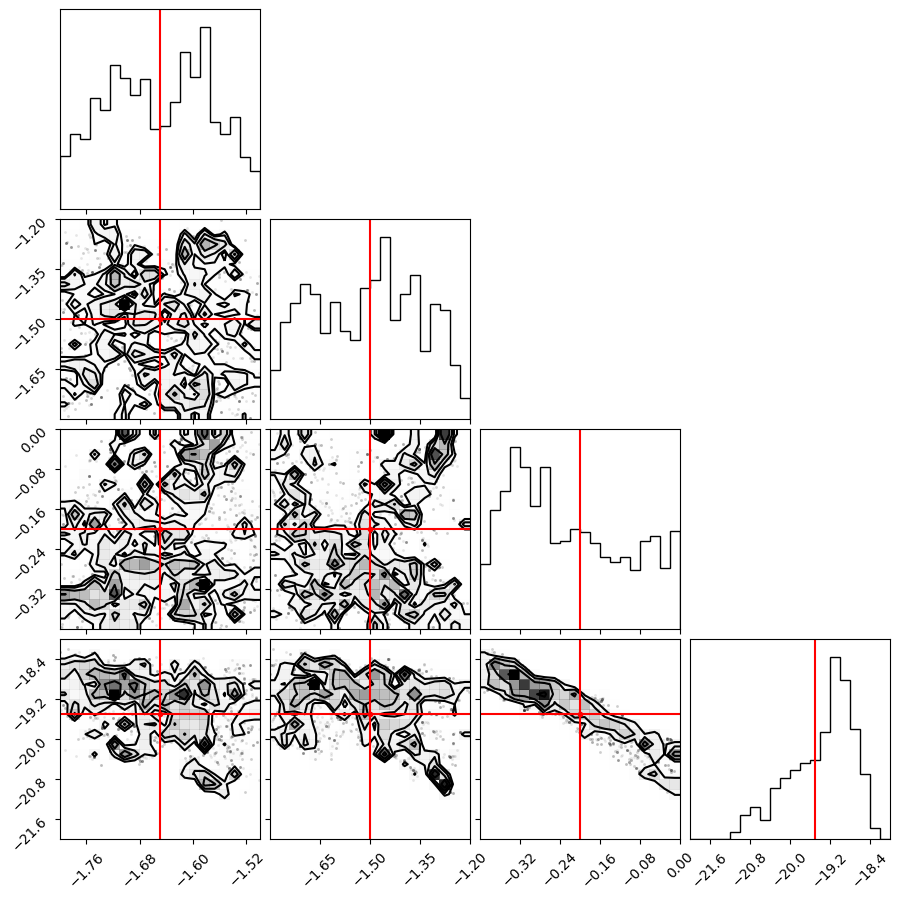

In [25]:
fig = DFM.corner(sampler.flatchain[5000:,:], range=[(-1.8, -1.5), (-1.8, -1.2), (-0.4, 0.0), (-22, -18)])
DFM.overplot_points(fig, [phi_true], color='red')
DFM.overplot_lines(fig, phi_true, color='red')
#DFM.overplot_lines(fig, np.median(sampler.flatchain[5000:,:], axis=0), color='blue')

In [42]:
ndim, nwalkers = 4, 10
# 1. initialize walkers by sampling uniformly from inside the prior
# (avoids stuck walkers near boundaries)
p0 = np.array([
  np.random.uniform(-1.8, -1.5, nwalkers),
  np.random.uniform(-1.8, -1.2, nwalkers),
  np.random.uniform(-0.4,  0.0, nwalkers),
  np.random.uniform(-22.,  -18., nwalkers),
]).T
      
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior1)
_ = sampler.run_mcmc(p0, 10000, progress=True)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [17:37<00:00,  9.46it/s]


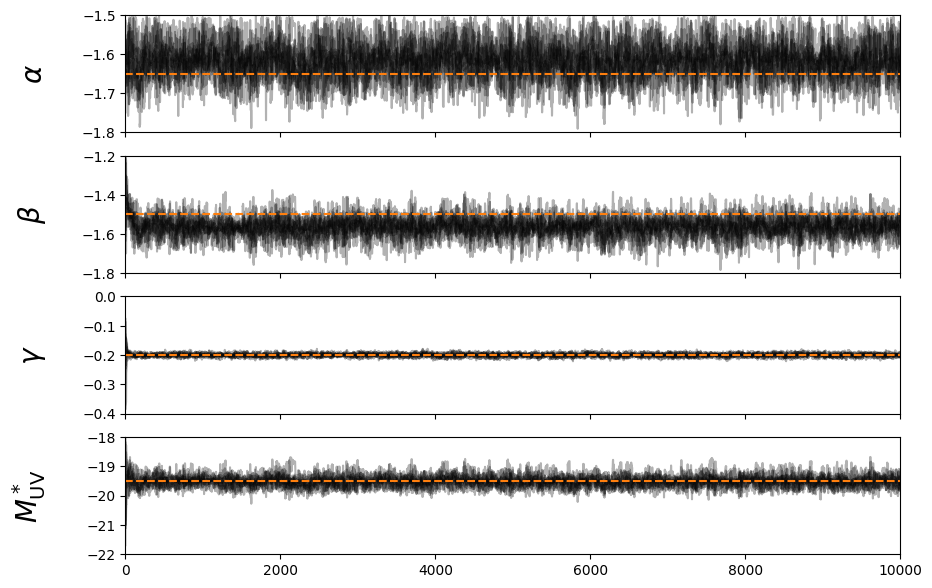

In [43]:
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.plot([0, samples.shape[0]], [phi_true[i], phi_true[i]], c='C1', ls='--')
    ax.set_xlim(0, len(samples))
    ax.set_ylabel([r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$'][i], fontsize=20)
    ax.yaxis.set_label_coords(-0.1, 0.5)
    ax.set_ylim([(-1.8, -1.5), (-1.8, -1.2), (-0.4, 0.0), (-22, -18)][i])

In [47]:
_samps.shape

(5000, 4)

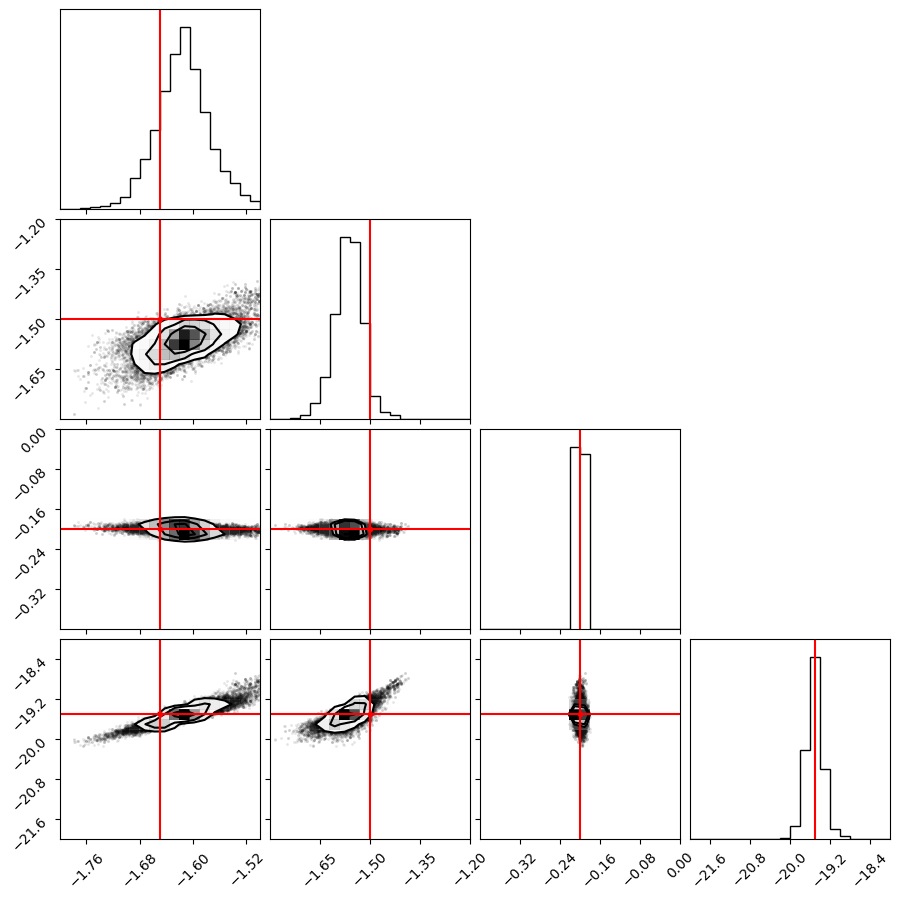

In [50]:
_samps = sampler.get_chain(thin=2, discard=5000, flat=True) 
fig = DFM.corner(_samps, range=[(-1.8, -1.5), (-1.8, -1.2), (-0.4, 0.0), (-22, -18)])
DFM.overplot_points(fig, [phi_true], color='red')
DFM.overplot_lines(fig, phi_true, color='red')
#DFM.overplot_lines(fig, np.median(sampler.flatchain[5000:,:], axis=0), color='blue')

(2e-05, 0.1)

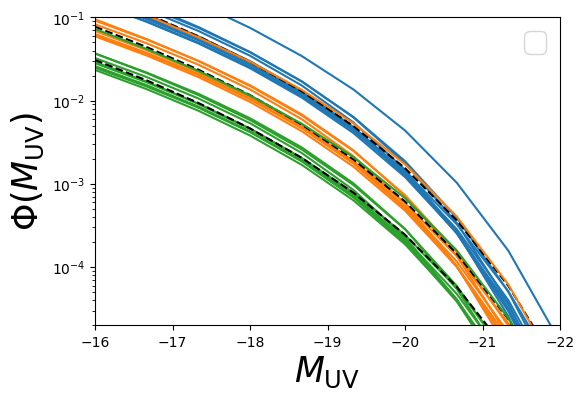

In [29]:
fig = plt.figure(figsize=(6,4))
sub = fig.add_subplot(111)

phi_amp = 6e-3
Muv_bin = np.linspace(-16, -22, 10)
for i, z0 in enumerate([5., 7., 9.]): 
    for j in range(nwalkers): 
        sub.plot(Muv_bin, phi_amp*UT.LF(Muv_bin, z0, sampler.chain[j,-1,:]), c='C%i' % i)

    sub.plot(Muv_bin, phi_amp*UT.LF(Muv_bin, z0, phi_true), c='k', ls='--')

sub.legend(loc='upper right', handletextpad=0.1, fontsize=20)
sub.set_xlabel(r'$M_{\rm UV}$', fontsize=25)
sub.set_xlim(-16, -22)
sub.set_yscale('log')
sub.set_ylabel(r'$\Phi(M_{\rm UV})$', fontsize=25)
plt.ylim(2e-5, 1e-1)